[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kulinskij-tech/QuantumMechanics1/blob/main/QM_py/qm1_stac_zad.ipynb)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sympy 
from sympy import *

## Задачі
$\newcommand{\ket}[1]{\left.\left\vert\, #1\,\right. \right \rangle}$
$\newcommand{\bra}[1]{\left. \langle \, #1\, \right\vert}$
$\newcommand{\braket}[2]{\langle \,#1 \vert #2 \, \rangle}$
$\newcommand{\av}[3]{\left\langle \,#1 \left \vert\, #2 \,\right\vert #3 \,\right \rangle}$


__<a id='inftywell'>Задача</a>__
Визначте спектр стаціонарних станів частинки у $\infty$--глибокій потенціальній ямі $x \in [0,a]$ з граничними
умовами:
$$
  \psi(0) = \psi(a) = 0\,.
$$
<br>

__Рішення__ Рівняння Шредінгера в даному випадку є простим диференційним рівнянням. Накладаючи граничні умови дістаємо відповідь:
$$
-\frac{d^2}{d\,x^2}\psi = k^2\,\psi\,,\quad k^2 = \frac{2\,m\,E}{\hbar^2}\,,\\
\psi(x) = C\,\sin{k_{n}\,x}\,,\quad C= \sqrt{\frac{2}{a}}\,,\,\,\,\,
 k_{n} = \frac{\pi\,n}{a}\,,\,\, n \in
\mathbb{Z}\\
E_{n} = \frac{\hbar^2\,\pi^2}{2\,m\,a^2}\,n^2
$$
Очевидна повна аналогія із задачею курсу ММФ о нормальних коливаннях дроту із закріпленими кінцями.
***

In [4]:
psi,f,f0 = symbols('psi f f0',cls=Function)
x,a = symbols('x a',real=True)
k = Symbol('k',positive=True)
# b
diffeq=Eq(diff(f(x),x,2),-k**2*f(x))
sol0=dsolve(diffeq,f(x),ics={f(0):0})
sol0

Eq(f(x), C1*sin(k*x))

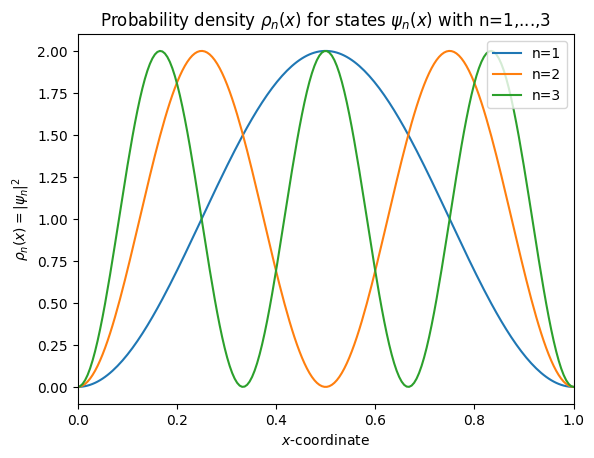

In [5]:
# Silly example data
bp_x = np.linspace(0, 1, num=200, endpoint=True)
# 
n0=3 # number of states
# 
psi2arr = [(np.sqrt(2)*np.sin((i+1)*np.pi*bp_x))**2 for i in range(n0)]
# 
fig, ax = plt.subplots()
for i in range(n0): 
    ax.plot(bp_x, psi2arr[i],'C'+str(i),label=r'n='+str(i+1))
#         
plt.xlabel(r"$x$-coordinate")
plt.ylabel(r"$\rho_{n}(x)=|\psi_{n}|^2$")
plt.title(r"Probability density $\rho_{n}(x)$ for states $\psi_{n}(x)$ with n=1,...,"
          +str(n0))
plt.xlim(0, 1.)
plt.ylim(-0.1, 2.1)
plt.legend(loc="upper right")
plt.show()

__Задача__ Частинка вільно рухається на полупрямій $x>0$. Визначте граничні умови, які забезпечують самосопряженість гамільтоніана. Знайдіть вид хвильових функцій стаціонарних станів
для даних граничних умов і дайте їм фізичну інтерпретацію.<br>

__Рішення__ Результат можна отримати з "фізичних" міркувань. Стаціонарний стан з енергією $E = k^2$ (для спрощення 
$\frac{\hbar^2}{2m}=1$), в даному випадку є суперпозицією плоских хвиль:
$$
\psi(x) = \exp(-i\,k\,x)+C\,\exp(i\,k\,x)\,,
$$
де $C$ - стала. Умови ермітовості оператора Шредінгера,
тобто відсутність потоку ймовірності через границі області руху накладають обмеження $|C| = 1$
$$
\psi_{\alpha}(x) = \exp(-i\,k\,x)+\,\exp(i\,k\,x + i\,\alpha)\,,
$$
де $\alpha$ - фазовий зсув між "падаючою" та "віддзеркаленою" хвилями. Т.ч. наявність стінки еквівалентно зсуву фаз при віддзеркалені від неї. 

З точки зору загальної теорії поширення ермітових операторів той же результат представляється наступним чином (див. курс лекцій). Необхідно розглянути кількість ЛНЗ розвязків з $L_2(x>0)$ для рівнянь (т.з. дефектні числа):

\begin{align}
\hat{H}\psi = \pm\,i\,\psi\,,\label{hpm}& \\ \quad
-\,\frac{d^2}{d\,x^2}\psi = e^{\pm\,i\,\pi/2}\,\psi\,,&\qquad
\int\limits_{0}^{+\infty}|\psi(x)|^2\,d\,x < +\infty \notag
\end{align}

Таких розв'язків всього два (по одному на кожне рівняння \eqref{hpm}):
$$
\psi_{-i}(x) = C\,\exp\left(-e^{i\,\pi/4}\,x\right)\,,\quad
\psi_{+i}(x) = C\,\exp\left(-e^{-i\,\pi/4}\,x\right)\,.
$$
Дефектні числа дорівнюють $ N_{+} = 1 = N_{-`}$, тому самоспряженні поширення такого оператора параметризуються комплексним числом $z =\exp(i\,\gamma)$. Згідно з формулою Неймана:
$$
\tilde \psi(x) = \psi(x)-
C\,\exp\left(-e^{i\,\pi/4}\,x\right)+ C\,\exp\left(-e^{-i\,\pi/4}\,x
+i\,\gamma\right)\,.
$$
Т.ч. початкова область визначення ермітова оператора $\hat{H}$, яка складається наприклад з функцій, які задовільняють граничним умовам:
\begin{equation}\label{eq:psi0}
  \psi(0)=\psi'(0)=0\,,
\end{equation}
розширюється до множини функцій з граничними значеннями для них та їх
похідних на стінці:
\begin{gather}
\psi(0) = -C\left(1-\exp(i\,\gamma)\right) =
2\,i\,C\exp\left(\frac{i\,\gamma}{2}\right)\sin\frac{\gamma}{2} \notag \\ \psi'(0) =
C\,e^{i\,\pi/4}- C\,e^{-i\,\pi/4}\exp\left(i\,\gamma\right) =
2\,i\,C\,\exp\left(\frac{i\,\gamma}{2}\right)
\sin\left(\frac{\pi}{4}-\frac{\gamma}{2}\right)\label{gran}
\end{gather}
ці умови можна записати у вигляді
\begin{equation}
\frac{\psi'(0)}{\psi(0)} = \tan \alpha\,,\quad \tan \alpha = \frac{\sin\left(\frac{\pi}{4}-\frac{\gamma}{2}\right)}{\sin\frac{\gamma}{2}}
\end{equation}
Таким чином дія ермітова оператора $\hat{H} = -\frac{d^2}{d\,x^2}$, на множині функцій \eqref{eq:psi0} розширюється до самосопряженого оператора с такими граничними умовами. З фізичної точки зору вони відповідають умові зникнення потоку ймовірності на границі $x=0$
$$
j(0) = {\rm Im}\,\left( \psi^*(0)\,\psi'(0)\right)= 0
$$
***

__Задача__ Обчислите спектр стаціонарних станів частинки у прямокутній потенціальній
ямі скінечнної глибини $V_0$. Дослідить граничнй випадок $\delta$-образного потенціала,
$$
V_0\to \infty\,,\,\,\,\,a \to 0\,,\,\,\,\,\,V_0\,a = const
$$
<br>
__Рішення__  Розглянемо локалізовані стани $E<0$. Рішення рівняння Шредінгера у відповідих областях має вигляд:
$$\psi(x) = \left\{\begin{array}{ll}
  A\,\exp(\varkappa\,x)\,,&\,\, x \le 0\\
  C\,\sin(k\,x)+D\,\cos(k\,x)\,,&\,\, x \in
  [0,a]\\
    B\,\exp(-\varkappa\,x)\,,&\,\, x \ge a
\end{array}\right.
$$
де 
$$
\varkappa^2 = -\frac{2\,m\,E}{\hbar^2}>0\,,\quad k^2 =
\frac{2\,m\,(E+V_0)}{\hbar^2} = k_0^2 - \varkappa^2 >0\,,\quad
k_0^2=\frac{2\,m\,V_0}{\hbar^2}\,.
$$ 
Запишемо <a id='coeffsys'>умову неперервності функції та її похідної на границі областей</a>:
\begin{equation}\label{eq:coeffsys}\left\{\begin{array}{rcl}
  A&=&D\\
\varkappa\, A&=&k\,C\\
  C\,\sin(k\,a)+D\,\cos(k\,a)&=&B\,\exp(-\varkappa\,a)\\
  k\,C\,\cos(k\,a)-k\,D\,\sin(k\,a)&=&-\varkappa\,B\,\exp(-\varkappa\,a)\\
\end{array}\right.
\end{equation}
Нетривіальні розв'язки для однорідної системи \eqref{eq:coeffsys} можливі тільки якщо детермінант дорівнює 0. Обчислимо детермінант:

In [6]:
syseq, a1,a2, a21, a22, a3= symbols('syseq a1 a2 a21 a22 a3')
x, a, k, kappa, q, alpha = symbols('x a k kappa q alpha',real=True)

psi1= a1*exp(kappa*x)
psi2= a21*sin(k*x)+a22*cos(k*x)
psi3= a3*exp(-kappa*x)
coeff=[a1,a21,a22,a3]
syseq=[(psi1-psi2).subs(x,0),diff((psi1-psi2),x).subs(x,0),(psi2-psi3).subs(x,a),diff((psi2-psi3),x).subs(x,a)]
coeffmtrx=Matrix(4,4,lambda i,j: diff(syseq[i],coeff[j]))
coeffmtrx

Matrix([
[    1,          0,          -1,                   0],
[kappa,         -k,           0,                   0],
[    0,   sin(a*k),    cos(a*k),      -exp(-a*kappa)],
[    0, k*cos(a*k), -k*sin(a*k), kappa*exp(-a*kappa)]])

In [7]:
det1=det_quick(coeffmtrx)
det1

k**2*exp(-a*kappa)*sin(a*k) - 2*k*kappa*exp(-a*kappa)*cos(a*k) - kappa**2*exp(-a*kappa)*sin(a*k)

використовуючи заміну
$$
\cos{k} \to \frac{1-\tan^2{\frac{k}{2}}}{1+\tan^2{\frac{k}{2}}}\,,\quad \sin{k} \to \frac{2\tan{\frac{k}{2}}}{1+\tan^2{\frac{k}{2}}}
$$
отримуємо наступний вираз для детермінанта:

In [8]:
urdet=simplify((det1.subs(cos(a*k),(1-tan(a*k/2)**2)/(1+tan(a*k/2)**2))).subs(sin(a*k),(2*tan(a*k/2))/(1+tan(a*k/2)**2)))
urdet

2*(k**2*tan(a*k/2) + k*kappa*(tan(a*k/2)**2 - 1) - kappa**2*tan(a*k/2))*exp(-a*kappa)*cos(a*k/2)**2

для $\tan{\frac{k}{2}}$ отримуємо такі розв'язки

In [9]:
solve(urdet,tan(a*k/2))

[kappa/k, -k/kappa]

$$
\tan\frac{k\,a}{2}=\frac{\varkappa}{k} = \frac{\sqrt{k^2_0 - k^2}}{k}\,,\quad
 \tan\frac{k\,a}{2}=\,-\frac{k}{\varkappa} = - \frac{k}{\sqrt{k^2_0 - k^2}}
$$

In [10]:
print(det1)
solveset(det1.subs([(a,1),(sin(k),2*tan(k/2)/(1+tan(k/2)**2)),(cos(k),(1-tan(k/2)**2)/(1+tan(k/2)**2))]),tan(k/2))
#k=np.linspace(0,8*np.pi,100) plt.plot(k,np.tan(k/2))

k**2*exp(-a*kappa)*sin(a*k) - 2*k*kappa*exp(-a*kappa)*cos(a*k) - kappa**2*exp(-a*kappa)*sin(a*k)


Complement({kappa/k, -k/kappa}, {-I, I})

Ці рівняння аналізуємо графічно. Корінь першого рівняння існує завжди. Це стани в яких хвильова функція у координатному просторі є парною. Т.ч. у прямокутної ямі існує зв'язаний стан. Корені другого рівняння існують якщо $k_0 a/2\ge \pi/2$.
Це "непарні" стани.

<img src="./figs/fig_pltevenodd.gif" alt="Image">    

Видно що у границі $V_{0}\to \infty$ відтворюються результати [Задачі про нескінченну яму](#inftywell). <br>
***
У граничному випадку $\delta$-потенціала хвильова функція єдиного(!) зв'язаного стану:

$$\psi_0(x) = A\,\exp(-\varkappa\,|x|)\,.$$

[Граничні умови](#coeffsys) у даному випадку трансформуються за рахунок того, що область неперервності похідної стягується у точку і вона має стрибок у точції дії $\delta$-потенціала. Використвуючи асимптотику при $a\to 0\,,V_0\to \infty$ для першого рівняння \eqref{sqwell_even}, отримуємо:
\begin{equation}\label{tan1}
  \frac{2\,m\,V_0}{\hbar^2}\,a = 2\varkappa\,.
\end{equation}
Останньому співвідношенню можна надати "інваріантний" вигляд для стрибка логарифмічної похідної
$\frac{\psi'}{\psi}$:
\begin{equation}\label{delta}
\left.  \frac{d\,\psi}{d\,x}\right|_{x\to 0+} -\left.
\frac{d\,\psi}{d\,x}\right|_{x\to
  0-} = 2\,\Omega\,\psi(0)\,,\,\,\,\, \Omega =\lim\limits_{a\to 0\,,\,V_0\to \infty} -V_0\,a 
\end{equation}
Параметр $\Omega$ має розмірність зворотньої довжини. Т.ч. <a id= 'deltabarrier'>$\delta$-подібний потенціал</a>:
$$
V(x) = \frac{\hbar^2}{m}\Omega\,\delta(x)
$$
еквівалентний до граничної умови \eqref{delta}. 
***

Теперь розглянемо стани з $E>0$ - стани розсіяння. Хвильова функція, яка зображує частинку яка прийшла із джерела розташованого на $-\infty$, має вигляд:
$$
\psi(x) = \left\{\begin{array}{lll}
  \exp(ikx)+A\exp(-ikx)\,,&\,\, x \le 0\,,&k^2=\frac{2\,m\,E}{\hbar^2}\\
  B\,\exp(iqx)+C\,\exp(-iqx)\,,&\,\, x \in
  [0,a]\,,&q^2=k^2+k_0^2\\
  D\,\exp(ikx)&\,\, x \ge a&
\end{array}\right.
$$

In [11]:
psi1= exp(I*k*x)+a1*exp(-I*k*x)
psi2= a21*exp(I*q*x)+a22*exp(-I*q*x)
psi3= a3*exp(I*k*x)
coeff=[a1,a21,a22,a3]
syseq=[(psi1-psi2).subs(x,0),diff((psi1-psi2),x).subs(x,0),
       (psi2-psi3).subs(x,a),diff((psi2-psi3),x).subs(x,a)]

In [12]:
syseq[0]

a1 - a21 - a22 + 1

In [13]:
syseq[1]

-I*a1*k - I*a21*q + I*a22*q + I*k

In [14]:
syseq[2]

a21*exp(I*a*q) + a22*exp(-I*a*q) - a3*exp(I*a*k)

In [15]:
syseq[3]

I*a21*q*exp(I*a*q) - I*a22*q*exp(-I*a*q) - I*a3*k*exp(I*a*k)

Т.ч. граничні умови:
<!--  -->
$$
\left\{\begin{array}{rcl}
  1+A&=&B+C\\
k(1-A)&=&q\,(B-C)\\
  B\,\exp(iqa)+C\,\exp(-iqa)&=&D\,\exp(ika)\\
 q(B\,\exp(iqa)-C\,\exp(-iqa))&=&k\,D\,\exp(ika)
\end{array}\right.
$$

визначають коефіцієнти:

In [16]:
solut=linsolve(syseq,coeff)
solut

{(k**2*exp(2*I*a*q)/(k**2*exp(2*I*a*q) - k**2 - 2*k*q*exp(2*I*a*q) - 2*k*q + q**2*exp(2*I*a*q) - q**2) - k**2/(k**2*exp(2*I*a*q) - k**2 - 2*k*q*exp(2*I*a*q) - 2*k*q + q**2*exp(2*I*a*q) - q**2) - q**2*exp(2*I*a*q)/(k**2*exp(2*I*a*q) - k**2 - 2*k*q*exp(2*I*a*q) - 2*k*q + q**2*exp(2*I*a*q) - q**2) + q**2/(k**2*exp(2*I*a*q) - k**2 - 2*k*q*exp(2*I*a*q) - 2*k*q + q**2*exp(2*I*a*q) - q**2), -2*k**2/(k**2*exp(2*I*a*q) - k**2 - 2*k*q*exp(2*I*a*q) - 2*k*q + q**2*exp(2*I*a*q) - q**2) - 2*k*q/(k**2*exp(2*I*a*q) - k**2 - 2*k*q*exp(2*I*a*q) - 2*k*q + q**2*exp(2*I*a*q) - q**2), 2*k**2*exp(2*I*a*q)/(k**2*exp(2*I*a*q) - k**2 - 2*k*q*exp(2*I*a*q) - 2*k*q + q**2*exp(2*I*a*q) - q**2) - 2*k*q*exp(2*I*a*q)/(k**2*exp(2*I*a*q) - k**2 - 2*k*q*exp(2*I*a*q) - 2*k*q + q**2*exp(2*I*a*q) - q**2), -4*k*q*exp(I*a*q)/(k**2*exp(I*a*k)*exp(2*I*a*q) - k**2*exp(I*a*k) - 2*k*q*exp(I*a*k)*exp(2*I*a*q) - 2*k*q*exp(I*a*k) + q**2*exp(I*a*k)*exp(2*I*a*q) - q**2*exp(I*a*k)))}

In [17]:
solut,=linsolve(syseq,coeff) # "," means seqence unpacking
simplify(solut[0])

(-k**2*exp(2*I*a*q) + k**2 + q**2*exp(2*I*a*q) - q**2)/(-k**2*exp(2*I*a*q) + k**2 + 2*k*q*exp(2*I*a*q) + 2*k*q - q**2*exp(2*I*a*q) + q**2)

In [18]:
simplify(solut[1])

2*k*(k + q)/(-k**2*exp(2*I*a*q) + k**2 + 2*k*q*exp(2*I*a*q) + 2*k*q - q**2*exp(2*I*a*q) + q**2)

In [19]:
simplify(solut[2])

2*k*(-k + q)*exp(2*I*a*q)/(-k**2*exp(2*I*a*q) + k**2 + 2*k*q*exp(2*I*a*q) + 2*k*q - q**2*exp(2*I*a*q) + q**2)

In [20]:
simplify(solut[3])

4*k*q*exp(I*a*(-k + q))/(-k**2*exp(2*I*a*q) + k**2 + 2*k*q*exp(2*I*a*q) + 2*k*q - q**2*exp(2*I*a*q) + q**2)

$$
A=\frac{q^2-k^2}
{(q+k)^2-(k-q)^2e^{2\,iqa}}\,\left(e^{2\,iqa}-1\right)\,,\quad 
B=\frac {2\,\left (k+q\right )k}{(q+k)^2-(k-q)^2e^{2\,iqa}}\,,\\
C=\frac {2\,k\left (q-k\right )
}{(q+k)^2-(k-q)^2e^{2\,iqa}}\,e^{2\,iqa}\,,\quad D=\frac
{4\,qk}{(q+k)^2-(k-q)^2e^{2\,iqa}}\,e^{i(q-k)a}\,.
$$
Легко перевірити співвідношення:
$$
|A|^2+|D|^2=1\,,
$$
-закон збереження числа частинок. 

In [21]:
simplify(solut[0]*conjugate(solut[0])+solut[3]*conjugate(solut[3]))==1

True

Визначемо залежність коефіциєнта прозорості $T=|D|^2$ барьера від $k\,, k_0$. 

In [22]:
v0 = symbols('v0',real=True)
tt=simplify(1/re(1/((solut[3]*conjugate(solut[3])).subs(a,1))))
tt
# print(tt)

4*k**2*q**2/(k**4*sin(q)**2 - 2*k**2*q**2*sin(q)**2 + 4*k**2*q**2 + q**4*sin(q)**2)

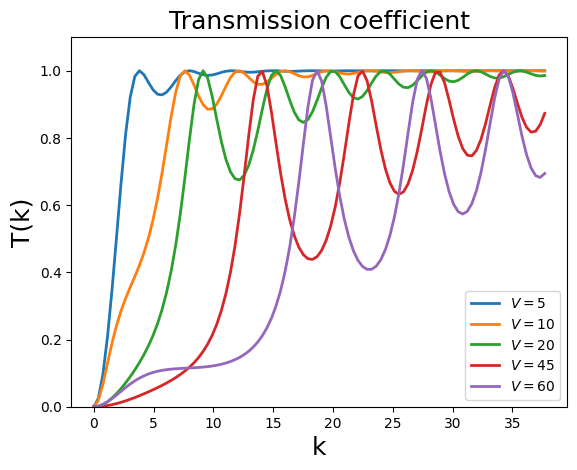

In [23]:
def tt(k,v0):
    q=np.sqrt(k**2 + v0**2)
    x=4*k**2*q**2
    y=(k**4*np.sin(q)**2 - 2*k**2*q**2*np.sin(q)**2 + 4*k**2*q**2 + q**4*np.sin(q)**2)
    return x/y
# 
k_x=np.linspace(1e-4,12*np.pi,num=100,endpoint=True)
# Silly example data
# Make the plot
for y in (5,10,20,45,60):
    plt.plot(k_x, tt(k_x,y), linewidth=2,
#          color="blue",
             label=r"$V = $"+str(y))
plt.xlabel(r"k",size=18)
plt.ylabel(r"T(k)",size=18)
plt.title(r"Transmission coefficient",size=18)
# plt.xlim(0, 2*np.pi)
plt.ylim(0., 1.1)
plt.legend(loc="lower right")
plt.show()

При збільшені $k$, значення $T$, швидко виходить на одиницю - класичну границю для амплітуди розсіяння. Тим не менше помітні осциляції (особливо при збільшені $k_0$)  - прояв хвильової природи руху квантових частинок, які навіть у випадку $E>0$ може відбитись від бар'єру (мінімуми прозорості).
Відмітимо, що якщо:
\begin{equation}\label{proz}
  q\,a = \pi \, n\,,\,\,\,\,\, n = 1,2,\ldots\,, \Rightarrow D = (-1)^n\, e^{-i\,k\,a}
\end{equation}
$A=0$ і відповідно $T =|D|^2=1$, тобто при виконанні співвідношення \eqref{proz} бар'єр є прозорим (резонансна прозорість). Це можна інтерпретувати як результат повного зникнення хвиль віддзеркалених від стрибків потенціалу завдяки інтерференції. Це фактична 1-вимірний варіант ефекту Рамзауера. 

Оскільки відхилення коэфіцієнта проходження від $1$ прямує до 0 із "виключенням" розсіювача ($a\to 0$ або $V_0\to 0$), то можна ввести означення "амплітуди розсіяння вперед":
$$
F = D - 1
$$
Очевидно, $0 \le |F|\le 2$: мінімальне значення $F=0$ у випадку резонансної прозорості із фазою розсіяної хвилі $k\,a = 2\,\pi\,n$. Максимальне значення $F=-2$ відповідає фазам $k\,a = \pi + 2\,\pi\,n$.
***

__Задача__ Розглянемо процес розсіяння на $\delta$-бар'єрі. Хвильова функція і граничні умові мають вигляд:
$$\psi(x) = \left\{\begin{array}{lll}
  \exp(ikx)+A\exp(-ikx)\,,&\,\, x \le 0\,,\\
  D\,\exp(ikx)&\,\, x \ge 0&
\end{array}\right.\,,$$

$$\left\{\begin{array}{rcl}
  1+A&=&D\\
i k D - i k (1-A)  &=& 2\, \Omega\,D
\end{array}\right.$$

Звідки отримуємо:
$$
A=\frac{\Omega}{-\Omega+i\,k}\,,\quad D= \frac{i\,k}{-\Omega+i\,k}\,\Rightarrow \,\,T = \frac{k^2}{\Omega^2+k^2}
$$
Видно, що відсутність внутрішнього масштабу $\delta$-потенціала призводить до відсутності "вікон прозорості", тобто резонансныих значень енергії для яких $T = 1$, що мало місце для потенціала скінченої ширини. Аналогічно попередньому, определим амплітуду розсіяння вперед на фоні проходящого пучка:
$$D=1+F\,,$$
тому 
$$
F=\frac{\Omega}{-\Omega+i\,k}\,,
$$ 
що співпадає з амплітудою $A$ розсіяння назад для такого потенціала. Співпадіння цих амплітуд очевидно відображає безструктурний характер $\delta$-потенціала. Випадок розсіяння на $\delta$-ямі відповідає заміні $\Omega \to -\Omega$.
***

__Задача__ Дослідіть можливість локализації частинки у потенціальній ямі:
$$
V(x) = \left\{\begin{array}{rl}
\infty\,,&\,\, x\le 0\\
  -V_0\,,&\,\, 0\le x\le a\\
0\,,&\,\, a< x
\end{array}\right.
$$

Прийняти, що на стінці хвильова функція дорівнює 0.
<br>

__Рішення__ Цей випадок є "половиною" попередньої задачи, якщо за граничну умову на стінці взяти $\psi(0) = 0$. Тоді можна очікувати що залишиться тільки гілка непарних розв'язків. В такому випадку при достатньо малому значенні глибини ями можливе зникнення зв'язаного стана оскільки стінка буде ефективно відштовхувати частинку.

Запишемо рівняння Шредінгера у відповідних областях:

\begin{equation}\label{usch}
  \psi'' = \left\{\begin{array}{rl}
    -k^2\,\psi\,\,\,, & x \in [0,a]\,,\quad k^2 = k_0^2-\varkappa^2 = \frac{2\,m\,(E+V_0)}{\hbar^2}>0 \\
    \varkappa^2\,\psi\,\,\,, & x>a\,,\quad \varkappa^2 =
    -\frac{2\,m\,E}{\hbar^2}>0\,.
  \end{array}\right.
\end{equation}

Квадратично-інтегровний розв'язок \eqref{usch}, який зникає у $x=0$
має вигляд:

\begin{equation}\label{rusch}
  \psi(x) = \left\{\begin{array}{cc}
    A\,\sin{k\,x}\,, & x \in [0,a]\,, \\
C\,\exp(-\varkappa\,x)\,,& x > a\,.
  \end{array}\right.
\end{equation}

Граничні умови визначають коефіцієнты $A$ и $C$:

\begin{align*}
    A\,\sin{ka}\phantom{-}\, =&\,\phantom{-}\,C\,\exp(-\varkappa\,a) \\
        k\,A\,\cos{ka} \phantom{-}\,=&
        \,-\varkappa\, C\,\exp(-\varkappa\,a)\,,
\end{align*}

і відповідно:

\begin{equation}\label{en}
  \tan{ka} = - \frac{k}{\varkappa} = - \frac{k}{\sqrt{k_0^2-k^2}}\,.
\end{equation}

Розв'язок цього рівняння вже було представлено раніше. Аналіз вказує що якщо:

$$k_0\,a < \frac{\pi}{2} \Rightarrow V_0 < \frac{\hbar^2\,\pi^2}{8\,m\,a^2}$$

то звязані стани відсутні. Кількість звязаних станів:

$$N = \left[\frac{k_0\,a}{\pi}-\frac{1}{2}\right]+1\,.$$


__Задача__ Частинка рухається на полупрямій $x>0$. У тоці $x=a$ є
[$\delta$-образный потенциальный барьер](#deltabarrier). Визначте стаціонарні стани системи. <br>

__Рішення__  З урахуванням результатів попередньої задачі, представимо хвильову функцію у вигляді:
<!--  -->
\begin{equation}\label{p1}
  \psi(x) = \left\{\begin{array}{ll}
  A_{I}\left(\exp(-i\,k\,x)+\exp(i\,k\,x+i\,\alpha)\right)\,,&x \in
  [0,a]\,,\\
 \exp(-i\,k\,x)+A_{II}\exp(i\,k\,x)\,,&\,\, x \ge a
\end{array}\right.
\end{equation}
<!--  -->
Граничні умови приводять до рівнянь на коефіцієнти:
<!--  -->
\begin{equation}\label{bc2}
  \left\{\begin{array}{rl}
A\,(\exp(i\,k\,a)+\exp(-i\,k\,a+i\,\alpha)) -
\exp(i\,k\,a)-\exp(-i\,k\,a +i\,\beta)=&0\\
\exp(i\,k\,a)-\exp(-i\,k\,a +i\,\beta)) -
A\,(\exp(i\,k\,a)-\exp(-i\,k\,a+i\,\alpha))
 =&-2\,i\,\frac{\Omega}{k}\psi(a)
\end{array}\right.
\end{equation}
<!--  -->
які дозволяють знайти розв'язок:
$$
A={\frac {-ik}{{e^{ika}}
\left(-ik{e^{-ika+i\alpha}}+\Omega\,{e^{ika}}+\Omega\,
{e^{-ika+i\alpha}}\right )}},
$$
$$e^{i\beta} =-{\frac{ik{e^{ika}}+
\Omega\,{e^{ika}}+\Omega\,{e^{-ika+i\alpha}}}{\left (-ik{e^{-ika+i
\alpha}}+\Omega\,{e^{ika}}+\Omega\,{e^{-ika+i\alpha}}\right )\left
({e ^{ika}}\right )^{2}}}\,.
$$
Останє рівняння має розв'язок, якщо
$\alpha = \pi$.
Набіг фази завдяки бар'єру:

$$e^{i\beta} =-\frac{k\,e^{ika}+2\,\Omega\sin{ka}
}{k\,e^{-ika}+2\,\Omega\sin{ka}}\,e^{-2ika}\,.$$

Амплітуда $A$ дорівнює:

$$A=-\,{\frac {ik}{ik+\Omega\,e^{2ika}-\Omega}}\,,$$

і визначає ймовірність знаходження частинки у області $x\in [0,a]$.

In [24]:
omega,k,q = symbols('omega k q',real=True)
# 
psi1= a1*(exp(I*k*x+I*alpha)+exp(-I*k*x))
psi2= exp(-I*k*x)+a2*exp(I*k*x)
coeff1=[a1,a2]
syseq1=[(psi1-psi2).subs(x,1),diff((psi2-psi1),x).subs(x,1)-2*omega*(psi2.subs(x,1))]
solut1=linsolve(syseq1,coeff1)
solut1

{(k/(k + I*omega*exp(I*alpha)*exp(2*I*k) + I*omega), k*exp(I*alpha)*exp(2*I*k)/(k*exp(2*I*k) + I*omega*exp(I*alpha)*exp(4*I*k) + I*omega*exp(2*I*k)) - I*omega*exp(I*alpha)*exp(2*I*k)/(k*exp(2*I*k) + I*omega*exp(I*alpha)*exp(4*I*k) + I*omega*exp(2*I*k)) - I*omega/(k*exp(2*I*k) + I*omega*exp(I*alpha)*exp(4*I*k) + I*omega*exp(2*I*k)))}

In [25]:
amp2=abs((I*k/(I*k+omega*(exp(2*I*k)-1))))**2
1/re(1/amp2)

k**2/(k**2 + 2*k*omega*sin(2*k) - 2*omega**2*cos(2*k) + 2*omega**2)

In [26]:
limit(1/re(1/amp2),k,0)

1/(4*omega**2 + 4*omega + 1)

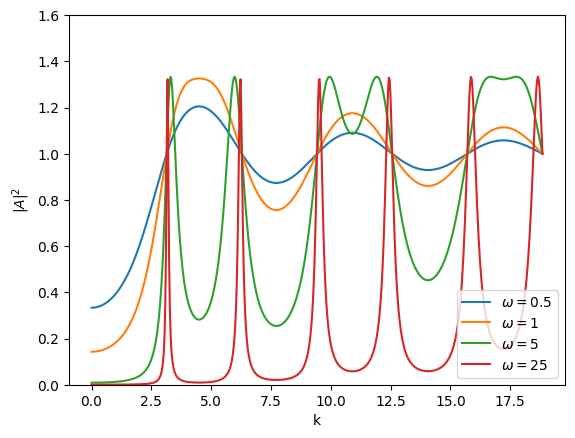

In [27]:
# 
def amp(k,om):
    return k**2/(2*om**2*(1-np.cos(2*k))+k**2+2*k*om*np.sin(k))
#
k_x=np.linspace(1e-4,6*np.pi,600)
#
for om in (0.5,1,5,25):
    plt.plot(k_x,amp(k_x,om),label='$\omega=$'+str(om))
#
plt.legend(loc='lower right')
plt.ylim(0., 1.6)
plt.xlabel('k')
plt.ylabel('$|A|^2$')
plt.show()

Для илюстрації на Рис. показана залежність $|A|^2$ від
параметра $ka$. На ньому чітко проявляються т.з. віртуальні рівні при $\omega \gg 1$,
які відповідають максимумам амплітуди $A$. У границі
$\Omega\, a \to \infty$ вони відповідають зв'язаним станам у
$\infty$-глубокій потенціальній ямі (див. [Задачу](#inftywell)).
***

__Задача__ <a id='kronigpenni'>Модель Кроніга-Пенні</a> одновимірного кристалу (Дираківська гребінка). Одновимірний кристал моделюється сукупністю $\delta$-образних потенціальних бар'єрів. Визначіть спектр частинки (электрона) в такому кристалі. <br>

__Розв'язок__ Власна функція оператора Шредінгера в області $x \in [0,a]$, має вигляд:
$$
\psi(x) = A\exp(ikx)+B\exp(-ikx)\,.
$$
Завдяки періодичності потенціала (теорема Блоха) у інтервалі $x\in [a, 2a]$ розв'язок має вигляд:
$$
\psi(x) = \exp(iqa)\left(A\exp(ik(x-a))+B\exp(-ik(x-a))\right)\,.
$$
Граничні умови в точці $x=a$:
\begin{gather*}
A\exp(ika)+B\exp(-ika)  = \exp(iqa)(A+B) \\ ik
(A\exp(ika)-B\exp(-ika))  = ik \exp(iqa)(A-B) -
2\,\Omega\,\exp(iqa)(A+B)
\end{gather*}
Умова існування розв'язку такої однорідної системи:

In [28]:
psi1=a1*sin(k*x)+a2*cos(k*x)
psi2=(a1*sin(k*(x-1))+a2*cos(k*(x-1)))*exp(I*q)
coeff=[a1,a2]
syseq=[(psi1-psi2).subs(x,1),(diff((psi2-psi1),x)-2*omega*psi1).subs(x,1)]
coeffmtrx=Matrix(2,2,lambda i,j: diff(syseq[i],coeff[j]))
zkp=simplify(expand(det(coeffmtrx))/(2*k*exp(I*q)))
zkp

-cos(k) + cos(q) - omega*sin(k)/k

$$
\cos{qa} = \cos{ka} + \frac{\Omega}{k}\,\sin{ka}
$$
веде до дисперсійного рівняння:
$$
\left\vert\cos{ka} +
\frac{\Omega}{k}\,\sin{ka}\right\vert\le 1\,\,\Rightarrow\,\,
\left\vert\cos\left(ka-{\rm atan}{\frac{\Omega}{k}}\right)\right\vert\le
\frac{1}{\sqrt{1+\left(\frac{\Omega}{k}\right)^2}}
$$
яке визначає дозволені зони енергії.

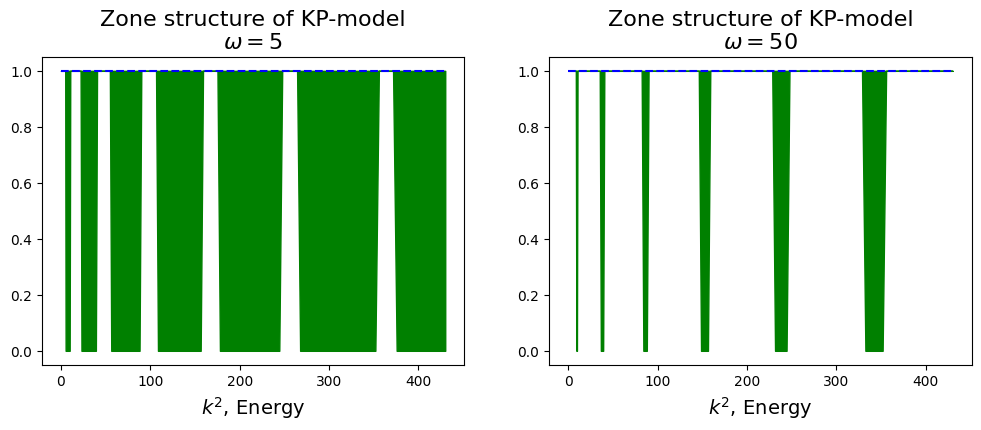

In [29]:
krange=(6.6*np.pi)
k2_x=np.linspace(10**(-4),krange,200)**2
k1_x=np.ones(200)
#
def zones1(k,x):
    return np.heaviside(abs(np.cos(k)+x*np.sin(k)/k)-1,1)
                           
#
_,ax = plt.subplots(1,2,sharex=True,figsize=(12, 4))
#plt.plot(k2,zones1,label='none',linestyle='-')
om=[5,50]
for i in range(len(om)):
    ax[i].plot(k2_x,k1_x,label='none',linestyle='--',color='b')
    ax[i].fill_between(k2_x, zones1(np.sqrt(k2_x),om[i]),1,color='g')
    ax[i].set_title(r"Zone structure of KP-model"#
             "\n" # 
             r"$\omega = $"+str(om[i]),fontsize=16)
    ax[i].set_xlabel(xlabel=r'$k^2$, Energy',fontsize=14)
plt.show()

__Задача__ Знайдіть енергетчний спектр і хвильові функції стаціонарних
станів у координатном представленії для одномерного квантового
осциллятора:
$$
\hat{H} = \frac{\hat{p}^2}{2\,m}+\frac{m\,\omega^2}{2}\,\hat{x}^2\,.
$$<br>
__Рішення__
Рівняння Шредінгера може бути переписано в
наступному вигляді:

\begin{align}
  \frac{d^2\,\psi}{d\, \xi^2} + (\varepsilon-\xi^2)\psi = 0\,.\label{osc_shrod_xi}\\
  \xi = x/x_0\,,\quad x_0^2 = \frac{\hbar}{m\,\omega}\,,\quad \varepsilon =
  \frac{2\,E}{\hbar\,\omega}\label{x0p0}
\end{align}

Оскільки асиптотично, при $\xi \to \infty$, \eqref{osc_shrod_xi}
зводиться до

\begin{equation}\label{xia}
  \frac{d^2\,\psi}{d\, \xi^2} -\xi^2\psi = 0
\end{equation}

Рішення доцільно шукати у вигляді:

$$\psi(\xi) = \exp\left(-\frac{\xi^2}{2}\right)\, f(\xi)\,,$$

Оскільки:

$$\psi''(\xi) = \exp\left(-\frac{\xi^2}{2}\right)\,
(f''(\xi)+\xi^2\,f(\xi)-2\,\xi\,f'(\xi)-f(\xi))\,.$$

підставляючи
це вираз у \eqref{osc_shrod_xi}, отримуємо:

\begin{equation}\label{xi1}
  f''-2\,\xi\,f'(\xi)+(\varepsilon - 1)\,f(\xi)=0\,
\end{equation}

Рішення \eqref{xi1} будем шукати у вигляді ряда:

\begin{equation}\label{ser}
  f(\xi) = \sum\limits_{n=0}^{\infty} a_n\,\xi^n\,.
\end{equation}

підставляючи \eqref{ser} у \eqref{xi1} отримаємо рівняння для
коэффициентов $a_n$:

\begin{equation}\label{an}
  a_{n+2} = \frac{2\,n+1-\epsilon}{(n+2)(n+1)}\,a_n
\end{equation}

Асимптотично, при $n\to \infty$ з \eqref{an} витікає що:
\begin{equation}\label{anas}
  a_{n+2} = \frac{2}{n}\,a_n\,,
\end{equation}
Це відповідає розкладу функції $\exp(\xi^2)$\,. Тобто якщо 
ряд \eqref{ser} не обірветься, ми не отримаємо нормований розв'язок.
Значення параметру $\varepsilon$, при яких функція $f$ є
многочленом дорівнюють $\varepsilon = 2\,n+1$, з чого виводимо рівні
энергії одномірного осцилятора:
$$
E_n = \hbar\,\omega\,\left(n+\frac{1}{2}\right)\,.$$
<a id='wfosc'>Хвильові функції відповідних стаціонарних станів мають вигляд</a>:
<!--  -->
\begin{equation}\label{wfn}
\psi_{n}(\xi) =
C_{n}\,H_{n}(\xi)\,\exp\left(-\frac{\xi^2}{2}\right)\,,
\end{equation}
<!--  -->
тут 
$$
H_n(-x) = (-1)^n\,H_n(x)
$$ 
где $H_{n}$ - т.з. поліноми Ерміта. Як витікає з попереднього вони задовільняють <a id='herniteq'>рівнянню</a>:
$$ \frac{d^2 H_n}{d x^2}-2\,x\,\frac{d H_n}{dx}+2\,n\,H_n=0\,.$$
***

## Задачі для самостійної роботи
__Задача__ Для 
для частинки у $\infty$--глибокій ямі $x \in [0,a]$ (див. [Задачу](#inftywell)) візуалізуйте еволюцію стана з рівномірним розподілом ймовірності:
$$
\psi(x,t)\vert_{t=0} = const
$$
***
__Задача__ Визначте спектр стаціонарних станів для частинки у $\infty$--глибокій ямі $x \in [0,a]$ з граничними
умовами:
$$
  \psi'(0) = \psi'(a) = 0\,.
$$
Перевірте співвідношення невизначеностей для стаціонарних станів.
***
__Задача__  Використовуючи характеристичну властивість вронскіана встановити співвідношення для матричних елементів матриці розсіяння 
$\hat{S}$ у 1-вимірній задачі розіяння яка взначається асимптотикою хвильової функції
$$
\psi_{-}(x)= A\,e^{i\,k\,x} +B\,e^{-i\,k\,x}\,, \quad x<0 \\
\psi_{+}(x)= C\,e^{i\,k\,x} +D\,e^{-i\,k\,x}\,, \quad x>0
$$
Вказівка: $\hat{S}$ діє на амплітуди падаючих хвиль $A,D$ переводячи їх у амплітуди розсіяних $B,C$.
$$
\begin{pmatrix}
B\\
C
\end{pmatrix} = \hat{S}\,\begin{pmatrix}
A\\
D
\end{pmatrix}
$$
***
__Задача__  Розв'яжіть задачу розсіяння частинки на прямокутному потенціальному бар'єрі:

$$V(x) = \left\{\begin{array}{rl}
V_0\,,&\,\, |\,x-a/2|\le a/2 \\
  0\,,&\,\, |\,x-a/2|\ge a/2
\end{array}\right.$$

***

__Задача__ Визначте стаціонарні стани розсіяння для частинки у полі потенціальной сходинки:
$$V(x) = V_0\,\theta(x)\,,$$ де $\theta(x)$ - функція Хевісайда: $\theta(x) = 1\,,$ якщо $x
\ge 0$ и $\theta(x) = 0\,,$ якщо $x < 0$.
***

__Задача__ Побудуйте спектр стаціонарних станів та дослідить локалізацію частинки у одновимірній потенціальній ямі виду:
$$
V(x) = \left\{
\begin{array}{rl}
  \infty\,, & x<0\,, \\
  -V_0\,, & 0 < x < a\,, \\
 0\,, & x > a\,,
\end{array}
\right.
$$
***

__Задача__ Дослідить локалізацію частинки у одновимірній потенціальній ямі виду:
$$
V(x) = \left\{
\begin{array}{rl}
  V_1\,, & x<0\,, \\
  V_0\,, & 0 < x < a\,, \\
  V_2\,, & x > a\,,
\end{array}
\right.
$$
де $V_1> V_2 > V_0$.
***
__Задача__ Знайдіть спектр частинки у $\infty$-ямі при наявності в неї потенціалу нульового радіусу.
***
__Задача__ Дослідіть спектр частинки на вісі при наявності двох потенціалів нульового радіусу, які знаходяться у точках $x=\pm a/2$ відповідно, в залежності від їх параметрів $\Omega_{\pm}$.
***
__Задача__ Визначте спектр енергії і хвильові функції частинки у потенціалі виду (на піввісі x>0):
$$V(x) =F_0\,x\,,\quad x > 0\,.$$
який моделює поле однорідної сили поблизу стінки.
***
__Задача__ Визначте спектр енергії і хвильові функції частинки у потенціалі виду (на піввісі):
$$V(x) =-e^2/x\,,\quad x > 0\,.$$
який моделює кулонівське  поле.
***
__Задача__
Виходячи з [рівняння для поліномів Ерміта](#herniteq), покажіть, що вони можуть бути отримані з генератриси (породжуючої функції):
$$
\exp(-t^2+2\,t\,x) = \sum\limits_{n=0}^{\infty} \frac{H_{n}(x)}{n!}\,t^n\,.
$$
тобто як коефіцієнти її ряду Тейлора.

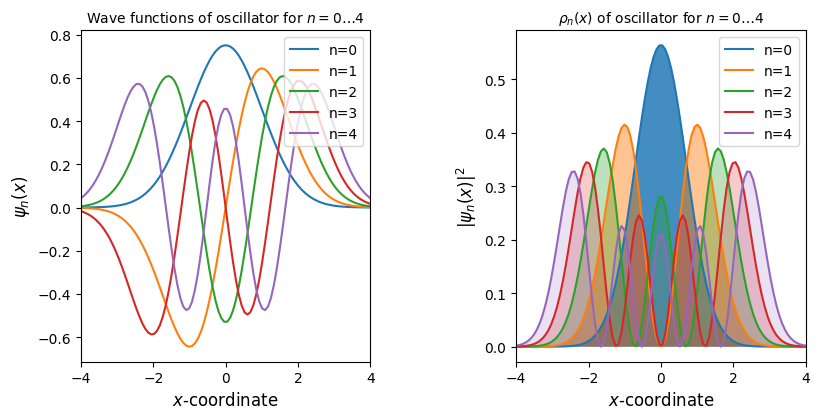

In [30]:
import numpy as np
import matplotlib.pyplot as plt
# 
from scipy import special
from scipy.special import factorial
x0,n0=4,5
# 
xosc=np.linspace(-x0, x0, num=100, endpoint=True)
wvpsiosc = [1/(np.sqrt(2**i*np.sqrt(np.pi)*factorial(i, exact=True)))*special.hermite(i)(xosc)*np.exp(-xosc**2/2) for i in range(n0)]
# 
psi2osc = [wvpsiosc[i]**2 for i in range(n0)]
# 
fig, ax = plt.subplots(nrows=1,ncols=2,layout='constrained',figsize=(8, 4))
# 
for i in range(n0):
    y=wvpsiosc[i]
    ax[0].plot(xosc, y, 'C'+str(i),label=r'n='+str(i))
    # 
ax[0].set_xlabel(r"$x$-coordinate",size=12)
ax[0].set_ylabel(r"$\psi_{n}(x)$",size=12)
ax[0].set_title(r"Wave functions of oscillator for $n=0\ldots$"+str(n0-1),size=10)
ax[0].set_xlim(-x0, x0)
# plt.ylim(-0.1, 0.6)
ax[0].legend(loc="upper right")
# 
for i in range(n0):
    y=psi2osc[i]
    ax[1].fill_between(xosc,y, alpha=1/(i+1.2))
    ax[1].plot(xosc, y, 'C'+str(i),label=r'n='+str(i))
  #     
ax[1].set_xlabel(r"$x$-coordinate",size=12)
ax[1].set_ylabel(r"$\vert\psi_{n}(x)\vert^2$",size=12)
ax[1].set_title(r"$\rho_{n}(x)$ of oscillator for $n=0\ldots$"+str(n0-1),size=10)
ax[1].set_xlim(-x0, x0)
# plt.ylim(-0.1, 0.6)
ax[1].legend(loc="upper right")
# 
fig.get_layout_engine().set(w_pad=0, h_pad=0, hspace=0, wspace=0.2)
plt.show()